In [2]:
# Importing all the Libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import openpyxl as op # To read and write excel file
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from tensorflow import keras as k
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.utils import plot_model

In [ ]:
stock_data = pd.read_excel("datasets/TATAMOTORS(Automobile).xlsx")

In [4]:
# Checking the Dataset

stock_data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1995-12-25,72.819626,72.819626,72.819626,72.819626,53.472767,0.0
1,1995-12-26,72.819626,72.819626,72.819626,72.819626,53.472767,0.0
2,1995-12-27,72.819626,72.819626,72.819626,72.819626,53.472767,0.0
3,1995-12-28,72.819626,72.819626,72.819626,72.819626,53.472767,0.0
4,1995-12-29,72.819626,72.819626,72.819626,72.819626,53.472767,0.0


In [5]:
#Displaying the structure of the dataset

stock_data.shape

(6814, 7)

In [6]:
# Check for the type of data 

stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6814 entries, 0 to 6813
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6814 non-null   datetime64[ns]
 1   Open       6807 non-null   float64       
 2   High       6807 non-null   float64       
 3   Low        6807 non-null   float64       
 4   Close      6807 non-null   float64       
 5   Adj Close  6807 non-null   float64       
 6   Volume     6807 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 372.8 KB


In [7]:
#Check for the Null- Values

stock_data.isnull().sum()

Date         0
Open         7
High         7
Low          7
Close        7
Adj Close    7
Volume       7
dtype: int64

In [8]:
#dropping the rows of the null values

stock_data.dropna()

#Filling the null values with 0

stock_data.fillna(0)

#Replacing the Null values with mean of the column

stock_data['Open'].fillna(value=stock_data['Open'].mean(),inplace=True)
stock_data['High'].fillna(value=stock_data['High'].mean(),inplace=True)
stock_data['Low'].fillna(value=stock_data['Low'].mean(),inplace=True)
stock_data['Close'].fillna(value=stock_data['Close'].mean(),inplace=True)
stock_data['Adj Close'].fillna(value=stock_data['Adj Close'].mean(),inplace=True)
stock_data['Volume'].fillna(value=stock_data['Volume'].mean(),inplace=True)

<Axes: >

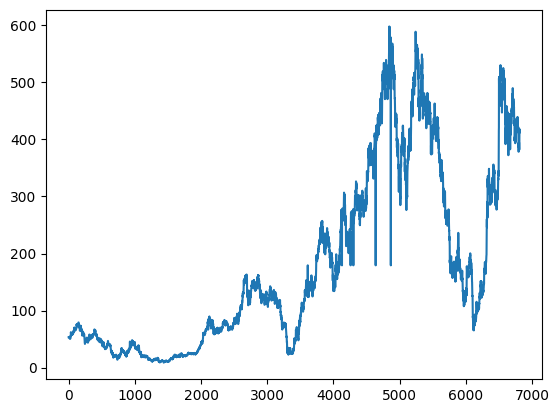

In [9]:
#plot the True Adj Close value

stock_data['Adj Close'].plot()

In [10]:
#Set Target variable

output_var=pd.DataFrame(stock_data['Adj Close'])

#selecting the Features

features=['Open','High','Low','Volume']

In [11]:
#Scaling

scaler=MinMaxScaler()
feature_transform = scaler.fit_transform(stock_data[features])
feature_transform= pd.DataFrame(columns=features, data=feature_transform, index=stock_data.index)
feature_transform.head()

,Open,High,Low,Volume
0,0.104745,0.102963,0.106749,0.0
1,0.104745,0.102963,0.106749,0.0
2,0.104745,0.102963,0.106749,0.0
3,0.104745,0.102963,0.106749,0.0
4,0.104745,0.102963,0.106749,0.0


In [12]:
#Splitting to Training set and Test set

timesplit= TimeSeriesSplit(n_splits=10)
for train_index, test_index in timesplit.split(feature_transform):
    X_train, X_test = feature_transform[:len(train_index)], feature_transform[len(train_index): (len(train_index)+len(test_index))]
    y_train, y_test = output_var[:len(train_index)].values.ravel(), output_var[len(train_index): (len(train_index)+len(test_index))].values.ravel()

In [13]:
#Process the data For LSTM

trainX =np.array(X_train)
testX =np.array(X_test)
X_train = trainX.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = testX.reshape(X_test.shape[0], 1, X_test.shape[1])

In [14]:
#Building the LSTM Model

lstm = Sequential()
lstm.add(LSTM(32, input_shape=(1, trainX.shape[1]), activation='relu', return_sequences=False))
lstm.add(Dense(1))
lstm.compile(loss='mean_squared_error', optimizer='adam')
plot_model(lstm, show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [15]:
# Model Training 

history=lstm.fit(X_train, y_train, epochs=100, batch_size=8, verbose=1, shuffle=False)

Epoch 1/100
775/775 [==============================] - 2s 1ms/step - loss: 34027.9531
Epoch 2/100
775/775 [==============================] - 1s 1ms/step - loss: 19055.7988
Epoch 3/100
775/775 [==============================] - 1s 1ms/step - loss: 9616.9863
Epoch 4/100
775/775 [==============================] - 1s 1ms/step - loss: 5202.6143
Epoch 5/100
775/775 [==============================] - 1s 2ms/step - loss: 2973.1230
Epoch 6/100
775/775 [==============================] - 1s 2ms/step - loss: 1388.4794
Epoch 7/100
775/775 [==============================] - 1s 2ms/step - loss: 500.7266
Epoch 8/100
775/775 [==============================] - 1s 1ms/step - loss: 171.6854
Epoch 9/100
775/775 [==============================] - 1s 1ms/step - loss: 88.3492
Epoch 10/100
775/775 [==============================] - 1s 1ms/step - loss: 72.6263
Epoch 11/100
775/775 [==============================] - 1s 1ms/step - loss: 69.6986
Epoch 12/100
775/775 [==============================] - 1s 1ms/step -

In [16]:
# LSTM Prediction
y_pred= lstm.predict(X_test)

20/20 [==============================] - 0s 1ms/step


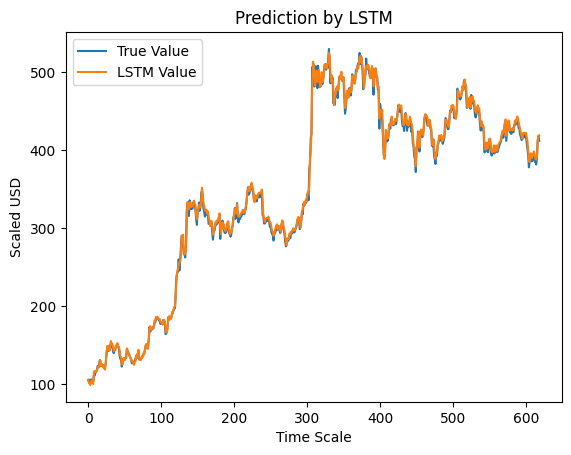

In [17]:
# Predicted vsTrue Adj Close value - LSTM

plt.plot(y_test, label='True Value')
plt.plot(y_pred, label='LSTM Value')
plt.title("Prediction by LSTM")
plt.xlabel('Time Scale')
plt.ylabel('Scaled USD')
plt.legend()
plt.show()